# Macro Regime–Conditional Risk Monitor — Analysis
### FINM 35900 · Virtu Financial · Antonio, Beckham, Christo, Kevin

**Approach: transparent, rule-based regimes.** Every regime is defined by explicit, economically
meaningful thresholds you can read off a slide and defend in Q&A — no black-box clustering. The
notebook is organized so each numbered section maps cleanly to one presentation slide.

**The one-sentence thesis.** Across history, certain macro regimes are the ones where implied
volatility systematically *underprices* the realized volatility that follows — and those same
regimes have the fattest left tails. For a market maker like Virtu, those are precisely the
states to pre-position against (reduce inventory, widen spreads, hedge harder).

**Notebook map → slides**
| § | Section | Slide |
|---|---------|-------|
| 0 | Setup | — |
| 1 | **Load & inspect all data** (coverage, sanity, plots) | 1–2 (data) |
| 2 | Define regimes with explicit rules | 3 (method) |
| 3 | Regime timeline & frequency | 3 (method) |
| 4 | VRP / "when IV underprices RV" per regime | 4 (result 1) |
| 5 | Fat tails per regime (SCOFT) | 5 (result 2) |
| 6 | Link to Virtu financials | 6 (result 3) |
| 7 | Risk-monitor output table | 7 (conclusion) |


## 0 · Setup

In [1]:
# !pip install pandas numpy matplotlib pyarrow scipy
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
PALETTE = {"Calm": "#4C9F70", "Inflationary": "#E1A730",
           "Tightening-stress": "#C44E52", "Crisis": "#7B2D26"}

DATA = Path("./data"); CLEAN, RAW = DATA/"clean", DATA/"raw"
FIG = Path("./figures"); FIG.mkdir(exist_ok=True)

def load(rel):
    fp = DATA/rel
    assert fp.exists(), f"MISSING {fp} — run the data-collection notebook first."
    df = pd.read_parquet(fp)
    return df
print("ready")

ready


## 1 · Load and inspect every dataset

Before any analysis we load all saved data and *look at it*: what's in each file, how much
coverage, and a sanity plot. This is the section that was missing before — it's also slide 1.

In [2]:
# Load everything saved by the collection notebook
panel    = load("clean/master_daily_panel.parquet")
derived  = load("clean/derived_vol_series.parquet")
fund_q   = load("raw/virt_fundamentals_q.parquet")
calendar = load("raw/release_calendar.parquet")
virt     = load("raw/virt_daily.parquet")

datasets = {"master panel (daily)": panel, "derived vol series": derived,
            "Virtu fundamentals (Q)": fund_q, "release calendar": calendar,
            "Virtu daily prices": virt}
rows = []
for name, df in datasets.items():
    idx = df.index if isinstance(df.index, pd.DatetimeIndex) else None
    span = (f"{idx.min().date()} → {idx.max().date()}" if idx is not None
            else f"{df['date'].min().date()} → {df['date'].max().date()}" if 'date' in df else "—")
    rows.append({"dataset": name, "rows": len(df), "cols": df.shape[1], "date span": span})
print("DATA INVENTORY")
display(pd.DataFrame(rows).to_string(index=False))

DATA INVENTORY


'               dataset  rows  cols               date span\n  master panel (daily)  5218    27 2006-01-02 → 2025-12-31\n    derived vol series  7007     8 2006-01-01 → 2025-12-31\nVirtu fundamentals (Q)    52    14                       —\n      release calendar  1243     3 2006-01-06 → 2025-12-23\n    Virtu daily prices  2695     7 2015-04-16 → 2025-12-31'

In [3]:
# Coverage check on the panel: how complete is each column? (catches silent gaps)
cov = pd.DataFrame({
    "non_null": panel.notna().sum(),
    "coverage_%": (panel.notna().mean()*100).round(1),
    "first_valid": panel.apply(lambda s: s.first_valid_index()),
    "last_valid": panel.apply(lambda s: s.last_valid_index()),
})
print("PANEL COLUMN COVERAGE")
display(cov)
print("\nNote: vrp_1m / rv_minus_iv_1m are blank for the final ~21 days BY DESIGN")
print("(they use the next 21 days of realized vol — the future isn't available yet).")

PANEL COLUMN COVERAGE


,non_null,coverage_%,first_valid,last_valid
vix,5058,96.9,2006-01-03,2025-12-31
rvol_trail_1m,4761,91.2,2006-02-01,2024-12-31
rv_minus_iv_1m,4760,91.2,2006-01-03,2024-11-29
vrp_1m,4760,91.2,2006-01-03,2024-11-29
volvol_realized_1m,216,4.1,2006-02-15,2008-10-31
vix_term,4548,87.2,2007-12-04,2025-12-31
dgs10,5003,95.9,2006-01-03,2025-12-31
dgs2,5003,95.9,2006-01-03,2025-12-31
dgs3mo,5003,95.9,2006-01-03,2025-12-31
t10y2y,5003,95.9,2006-01-03,2025-12-31



Note: vrp_1m / rv_minus_iv_1m are blank for the final ~21 days BY DESIGN
(they use the next 21 days of realized vol — the future isn't available yet).


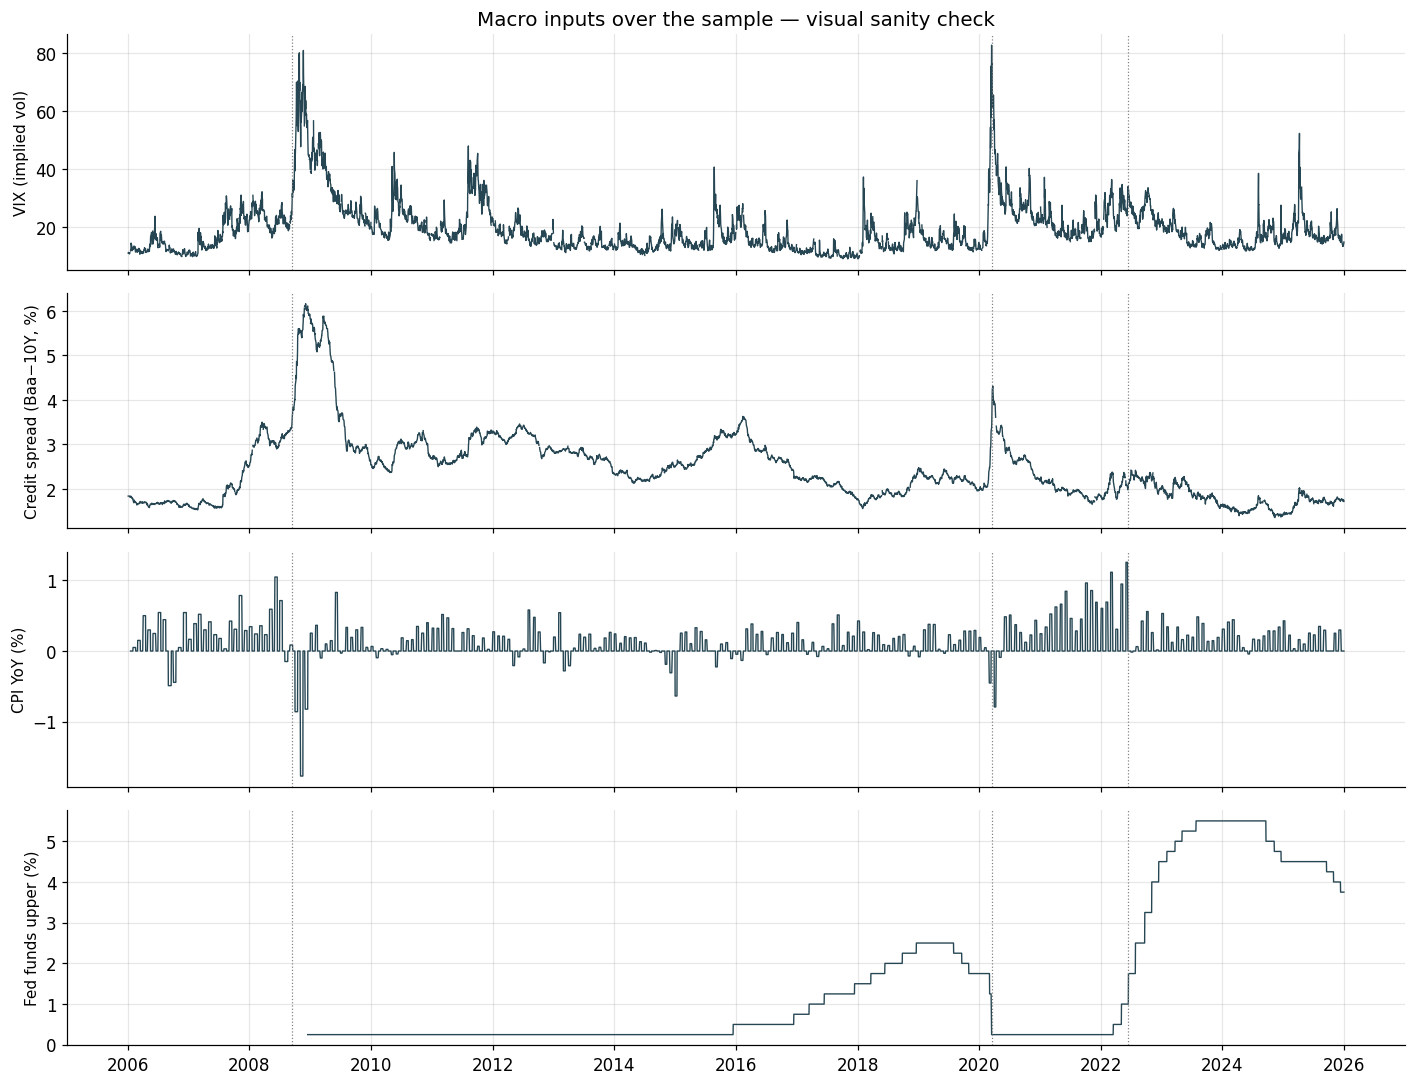

In [4]:
# Sanity plot: the four key macro series over time, with the big stress episodes marked.
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
series = [("vix", "VIX (implied vol)"), ("credit_spread", "Credit spread (Baa−10Y, %)"),
          ("cpi_yoy", "CPI YoY (%)"), ("fedfunds_upper", "Fed funds upper (%)")]
events = {"GFC 2008": "2008-09-15", "COVID 2020": "2020-03-16", "2022 hikes": "2022-06-15"}
for ax, (col, lab) in zip(axes, series):
    if col in panel:
        ax.plot(panel.index, panel[col], lw=0.9, color="#264653")
        ax.set_ylabel(lab, fontsize=10)
        for nm, dt in events.items():
            ax.axvline(pd.Timestamp(dt), color="grey", ls=":", lw=0.8)
axes[0].set_title("Macro inputs over the sample — visual sanity check", fontsize=13)
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout(); plt.savefig(FIG/"01_data_overview.png", bbox_inches="tight"); plt.show()

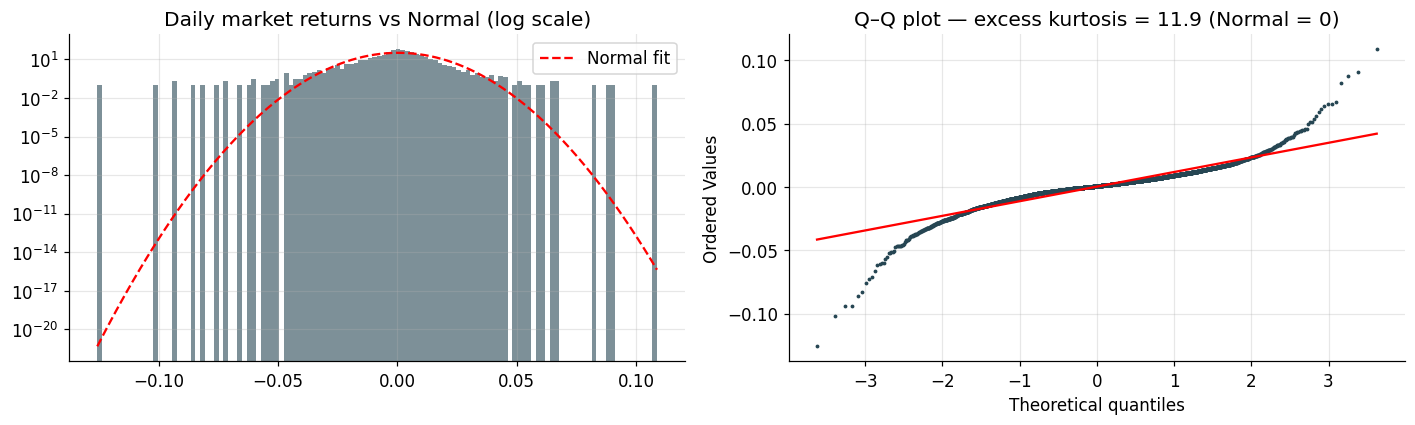

Excess kurtosis 11.9, min day -12.6%, max day 10.9%
=> returns are clearly fat-tailed; this is WHY the SCOFT tail analysis matters (§5).


In [5]:
# Look at the return distribution we'll be doing tail analysis on — is it actually fat-tailed?
r = derived["mkt_logret"].dropna()
from scipy import stats
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.hist(r, bins=120, density=True, alpha=0.6, color="#264653")
x = np.linspace(r.min(), r.max(), 300)
a1.plot(x, stats.norm.pdf(x, r.mean(), r.std()), "r--", lw=1.5, label="Normal fit")
a1.set_yscale("log"); a1.set_title("Daily market returns vs Normal (log scale)"); a1.legend()
stats.probplot(r, dist="norm", plot=a2)
a2.set_title(f"Q–Q plot — excess kurtosis = {r.kurtosis():.1f} (Normal = 0)")
a2.get_lines()[0].set(marker=".", markersize=3, color="#264653"); a2.get_lines()[1].set(color="r")
plt.tight_layout(); plt.savefig(FIG/"01_returns_fattail.png", bbox_inches="tight"); plt.show()
print(f"Excess kurtosis {r.kurtosis():.1f}, min day {r.min()*100:.1f}%, max day {r.max()*100:.1f}%")
print("=> returns are clearly fat-tailed; this is WHY the SCOFT tail analysis matters (§5).")

## 2 · Define the regimes — explicit rules

Four regimes, each defined by readable thresholds on **contemporaneous** variables (nothing
forward-looking). Thresholds use sample percentiles so they adapt to the data and are easy to
justify: "elevated VIX" = top third of history, etc. The order matters — we assign the most
severe matching condition first (Crisis beats Tightening-stress beats Inflationary beats Calm).

In [6]:
# Percentile thresholds (read off the data, stated explicitly for the slide)
vix_hi   = panel["vix"].quantile(0.80)          # acute implied-vol stress
vix_mid  = panel["vix"].quantile(0.60)
cr_hi    = panel["credit_spread"].quantile(0.75) # credit stress
cpi_hi   = panel["cpi_yoy"].quantile(0.70)       # elevated inflation
nfci_hi  = panel["nfci"].quantile(0.70) if "nfci" in panel else np.inf  # tight financial conditions

print("REGIME THRESHOLDS (sample percentiles):")
print(f"  VIX  : elevated > {vix_hi:.1f} (80th pct), moderate > {vix_mid:.1f} (60th)")
print(f"  Credit spread tight > {cr_hi:.2f}% (75th pct)")
print(f"  CPI YoY elevated > {cpi_hi:.1f}% (70th pct)")
print(f"  NFCI tight > {nfci_hi:.2f} (70th pct)")

def classify(row):
    vix, cr = row["vix"], row.get("credit_spread", np.nan)
    cpi, nfci = row.get("cpi_yoy", np.nan), row.get("nfci", np.nan)
    # 1) Crisis: acute vol AND credit/financial-conditions stress together
    if vix >= vix_hi and (cr >= cr_hi or (np.isfinite(nfci) and nfci >= nfci_hi)):
        return "Crisis"
    # 2) Tightening-stress: elevated vol without full-blown credit crisis
    if vix >= vix_mid:
        return "Tightening-stress"
    # 3) Inflationary: calm-ish vol but high inflation (the 'hawkish' macro state)
    if np.isfinite(cpi) and cpi >= cpi_hi:
        return "Inflationary"
    # 4) Calm: everything else
    return "Calm"

reg = panel.apply(classify, axis=1).rename("regime")
panel = panel.assign(regime=reg)
print("\nREGIME FREQUENCY:")
display(reg.value_counts().to_frame("days").assign(
    pct=lambda d: (d["days"]/d["days"].sum()*100).round(1)))

REGIME THRESHOLDS (sample percentiles):
  VIX  : elevated > 24.0 (80th pct), moderate > 18.8 (60th)
  Credit spread tight > 2.87% (75th pct)
  CPI YoY elevated > 0.1% (70th pct)
  NFCI tight > -0.35 (70th pct)

REGIME FREQUENCY:


,days,pct
regime,,
Calm,2200,42.2
Tightening-stress,1232,23.6
Inflationary,993,19.0
Crisis,793,15.2


In [7]:
# Enforce a minimum regime duration: any run shorter than MIN_RUN days gets absorbed
# into the regime that precedes it. Economically: you don't switch risk posture for a blip.
MIN_RUN = 10  # trading days (~2 weeks)

r = panel["regime"].copy()
# identify runs
grp = (r != r.shift()).cumsum()
run_len = r.groupby(grp).transform("size")
# walk forward, replacing too-short runs with the last "confirmed" regime
confirmed = r.copy()
last_good = r.iloc[0]
for g, sub in r.groupby(grp):
    if len(sub) >= MIN_RUN:
        last_good = sub.iloc[0]
    else:
        confirmed.loc[sub.index] = last_good
panel["regime"] = confirmed

print(f"After enforcing min run = {MIN_RUN} days:")
display(panel["regime"].value_counts().to_frame("days").assign(
    pct=lambda d: (d["days"]/d["days"].sum()*100).round(1)))

After enforcing min run = 10 days:


,days,pct
regime,,
Calm,2778,53.2
Tightening-stress,1177,22.6
Crisis,848,16.3
Inflationary,415,8.0


## 3 · Regime timeline — does it pass the eye test?

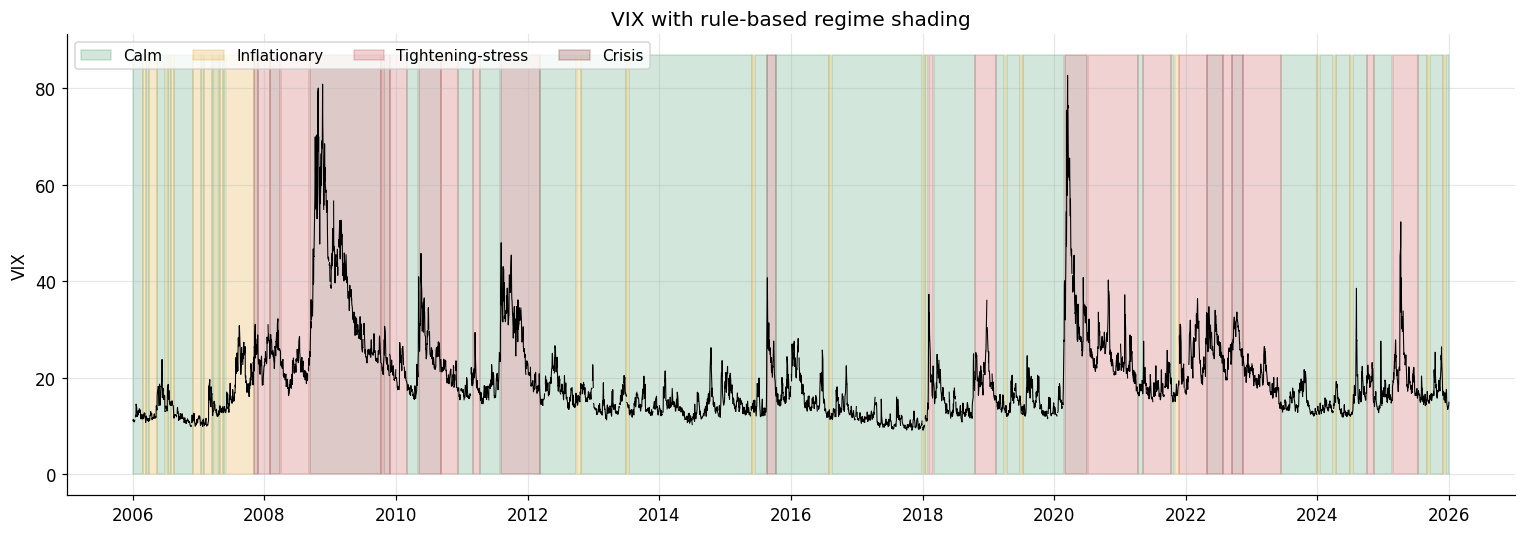

GFC (Oct 2008): {'Crisis': 0.93, 'Tightening-stress': 0.07}
COVID (Mar 2020): {'Crisis': 1.0}
2022 hikes: {'Crisis': 0.69, 'Tightening-stress': 0.31}


In [8]:
ORDER = ["Calm", "Inflationary", "Tightening-stress", "Crisis"]
fig, ax = plt.subplots(figsize=(14, 5))
vix = panel["vix"]
for r_ in ORDER:
    m = panel["regime"] == r_
    ax.fill_between(panel.index, 0, vix.max()*1.05, where=m, color=PALETTE[r_], alpha=0.25, label=r_)
ax.plot(vix.index, vix, color="black", lw=0.7)
ax.set_title("VIX with rule-based regime shading"); ax.set_ylabel("VIX")
ax.legend(loc="upper left", ncol=4, fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(2)); plt.tight_layout()
plt.savefig(FIG/"03_regime_timeline.png", bbox_inches="tight"); plt.show()

# Eye test: the famous stress windows should be Crisis/Tightening-stress
for nm, win in {"GFC (Oct 2008)": ("2008-09","2008-12"),
                "COVID (Mar 2020)": ("2020-03","2020-04"),
                "2022 hikes": ("2022-06","2022-10")}.items():
    s = panel.loc[win[0]:win[1], "regime"].value_counts(normalize=True).round(2)
    print(f"{nm}: {s.to_dict()}")

## 4 · Result 1 — When does implied vol underprice realized vol?

For each regime, the **variance risk premium** (`vrp_1m` = implied variance − next-month realized
variance). VRP < 0 means realized outran implied — options were too cheap, and a short-gamma
market maker takes losses. The headline number is the **share of days with VRP < 0** per regime.

VARIANCE RISK PREMIUM BY REGIME


,days,avg_RV_minus_IV,p95_RV_minus_IV,worst_RV_minus_IV,share_IV_underpriced
regime,,,,,
Calm,2524,-2.647,6.218,67.732,0.162
Inflationary,379,-1.496,7.028,12.996,0.335
Tightening-stress,1038,-5.198,4.519,34.852,0.152
Crisis,819,-4.044,14.557,60.271,0.178


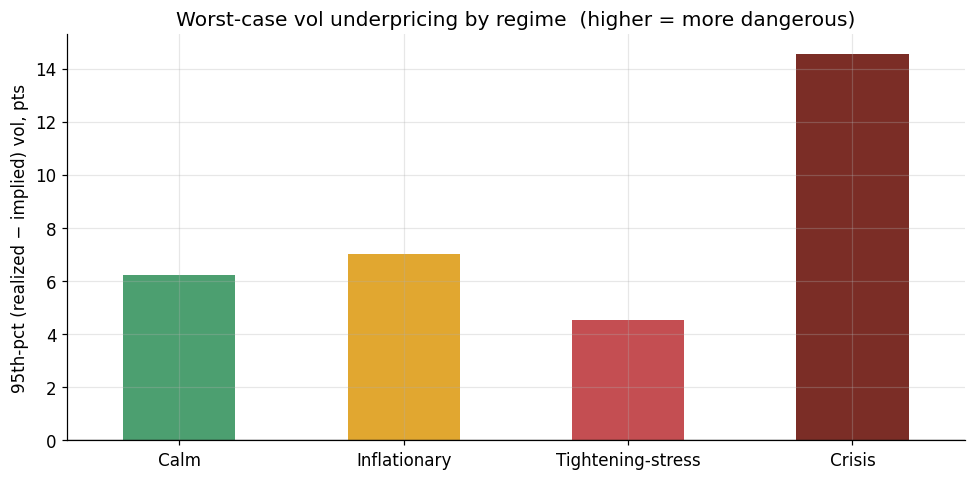

In [9]:
vrp = panel[["regime", "vrp_1m", "rv_minus_iv_1m"]].dropna()
res1 = vrp.groupby("regime").agg(
    days=("vrp_1m", "size"),
    avg_RV_minus_IV=("rv_minus_iv_1m", "mean"),
    p95_RV_minus_IV=("rv_minus_iv_1m", lambda s: s.quantile(0.95)),
    worst_RV_minus_IV=("rv_minus_iv_1m", "max"),
    share_IV_underpriced=("vrp_1m", lambda s: (s < 0).mean()),
).reindex(ORDER).round(3)
print("VARIANCE RISK PREMIUM BY REGIME")
display(res1)

# Headline = the WORST-CASE underpricing (95th pct of realized−implied). Positive & large
# means: when realized vol blew past implied, it blew past it hardest in this regime.
fig, ax = plt.subplots(figsize=(9, 4.5))
res1["p95_RV_minus_IV"].plot.bar(ax=ax, color=[PALETTE[r] for r in res1.index])
ax.set_ylabel("95th-pct (realized − implied) vol, pts")
ax.set_xlabel(""); ax.axhline(0, color="black", lw=0.8)
ax.set_title("Worst-case vol underpricing by regime  (higher = more dangerous)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig(FIG/"04_vrp_by_regime.png", bbox_inches="tight"); plt.show()

## 5 · Result 2 — Fat tails per regime (SCOFT / Taleb)

The contribution that makes this a *macro-finance* project, not just a vol study. In the
dangerous regimes, variance and kurtosis aren't trustworthy summaries because the moments may
not exist (Taleb, *Statistical Consequences of Fat Tails*). We measure the **Hill tail exponent
α** per regime (lower = fatter) and whether the **left tail is fatter than the right** (the
asymmetry that hurts a short-gamma book).

TAIL EXPONENTS BY REGIME (lower α = fatter tail; α<3 ⇒ 4th moment suspect)


,days,alpha_all,alpha_right(gains),alpha_left(losses),ann_vol_%,left_fatter
regime,,,,,,
Calm,2545,3.15,3.81,3.19,12.19,True
Inflationary,379,3.17,3.45,2.79,12.59,True
Tightening-stress,1038,3.85,4.79,3.89,17.06,True
Crisis,819,2.83,2.85,2.66,36.37,True


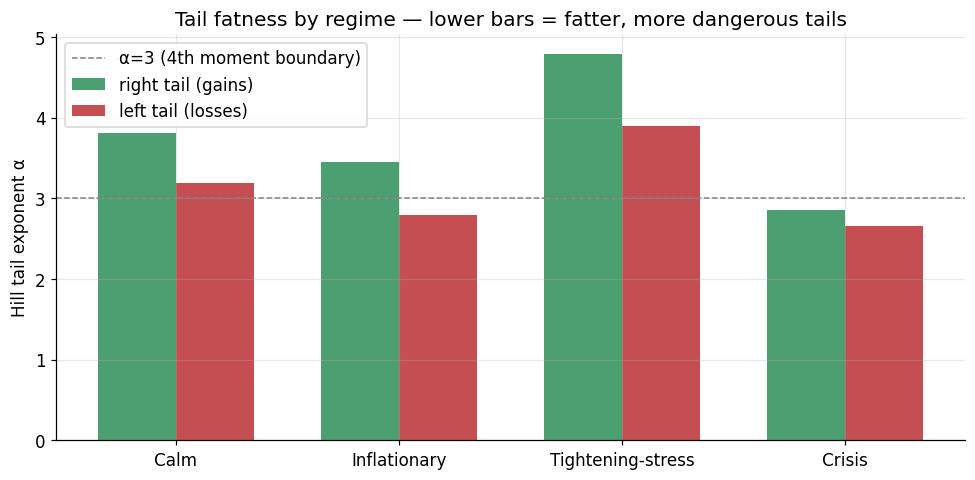

In [10]:
def hill_alpha(x, k_frac=0.10):
    a = np.sort(np.abs(np.asarray(x, float))); a = a[a > 0]; n = len(a)
    if n < 40: return np.nan
    k = max(int(k_frac*n), 10); lg = np.log(a[-(k+1):])
    xi = (lg[1:]-lg[0]).mean()
    return 1/xi if xi > 0 else np.inf

# Align returns to the panel's index so the regime mask lines up (this was the crash).
rets = derived["mkt_logret"].reindex(panel.index)
reg_aligned = panel["regime"]

rows = []
for r_ in ORDER:
    rr = rets[reg_aligned == r_].dropna().values
    if len(rr) < 40:
        continue
    rows.append({"regime": r_, "days": len(rr),
                 "alpha_all": hill_alpha(rr),
                 "alpha_right(gains)": hill_alpha(rr[rr > 0]),
                 "alpha_left(losses)": hill_alpha(-rr[rr < 0]),
                 "ann_vol_%": rr.std()*np.sqrt(252)*100})
res2 = pd.DataFrame(rows).set_index("regime").round(2)
res2["left_fatter"] = res2["alpha_left(losses)"] < res2["alpha_right(gains)"]
print("TAIL EXPONENTS BY REGIME (lower α = fatter tail; α<3 ⇒ 4th moment suspect)")
display(res2)

fig, ax = plt.subplots(figsize=(9, 4.5))
w = 0.35; x = np.arange(len(res2))
ax.bar(x-w/2, res2["alpha_right(gains)"], w, label="right tail (gains)", color="#4C9F70")
ax.bar(x+w/2, res2["alpha_left(losses)"], w, label="left tail (losses)", color="#C44E52")
ax.axhline(3, color="grey", ls="--", lw=1, label="α=3 (4th moment boundary)")
ax.set_xticks(x); ax.set_xticklabels(res2.index, rotation=0)
ax.set_ylabel("Hill tail exponent α"); ax.legend()
ax.set_title("Tail fatness by regime — lower bars = fatter, more dangerous tails")
plt.tight_layout(); plt.savefig(FIG/"05_tails_by_regime.png", bbox_inches="tight"); plt.show()

## 6 · Result 3 — Does this show up in Virtu's financials?

We aggregate to quarterly and align regime mix + realized market vol with Virtu's revenue
(`revtq`) and cash buffer (`cheq`). The market-maker pattern we expect: volatility *helps*
revenue (wider spreads, more volume) but coincides with *larger* cash buffers (defensive
liquidity). Note: Virtu data starts at its 2015 IPO, so this is a post-2015 window.

QUARTERLY: Virtu vs macro stress  (last 8)


,revtq,niq,cheq,mkt_vol_q,stress_regime_share
datadate,,,,,
2024-03-31,642.84,55.82,931.88,10.99,0.00
2024-06-30,692.98,66.59,1509.96,10.43,0.00
2024-09-30,706.84,59.95,1618.66,15.75,0.00
2024-12-31,834.28,94.06,2121.51,12.64,0.47
2025-03-31,837.87,99.68,2150.55,<NA>,0.41
2025-06-30,932.58,151.19,2110.51,<NA>,1.00
2025-09-30,824.79,77.63,2430.86,<NA>,0.14
2025-12-31,969.89,139.86,2368.38,<NA>,0.00



Correlations:


,mkt_vol_q,stress_regime_share
revtq,0.52,0.51
cheq,0.02,0.18


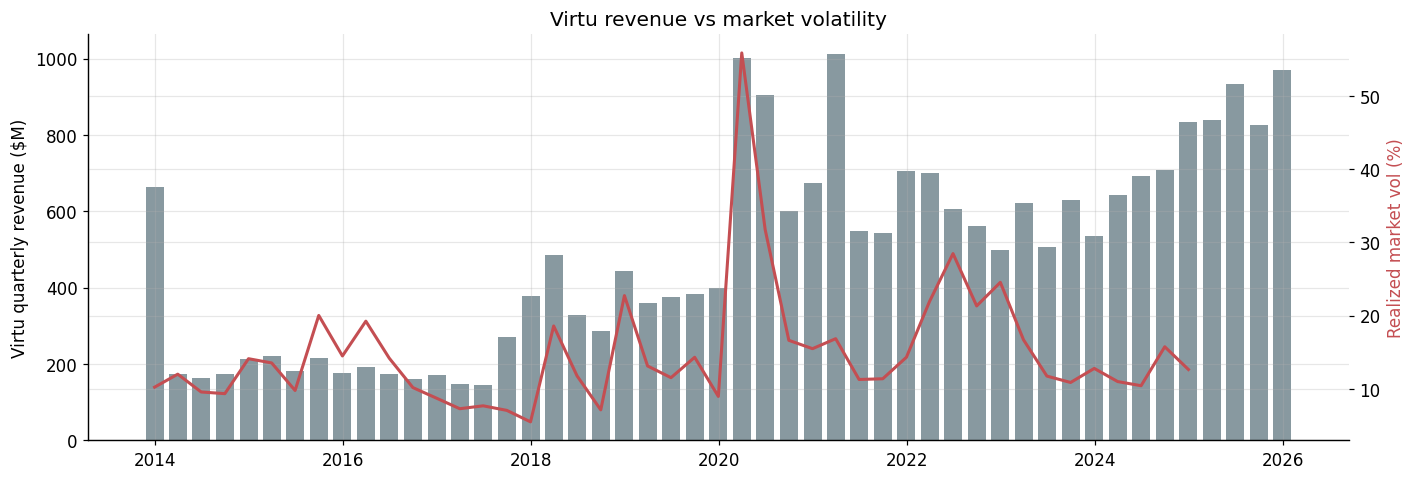

In [11]:
mkt_vol_q = (derived["mkt_logret"].resample("QE").std()*np.sqrt(252)*100).rename("mkt_vol_q")
stress_share_q = (panel["regime"].isin(["Tightening-stress","Crisis"])
                  ).resample("QE").mean().rename("stress_regime_share")
f = fund_q.copy(); f["datadate"] = pd.to_datetime(f["datadate"])
f = f.set_index("datadate").sort_index()[["revtq","niq","cheq"]].resample("QE").last()
q = f.join(mkt_vol_q).join(stress_share_q).dropna(subset=["revtq"])
print("QUARTERLY: Virtu vs macro stress  (last 8)")
display(q.tail(8).round(2))
print("\nCorrelations:")
display(q[["revtq","cheq","mkt_vol_q","stress_regime_share"]].corr().round(2)
        .loc[["revtq","cheq"], ["mkt_vol_q","stress_regime_share"]])

fig, ax1 = plt.subplots(figsize=(13, 4.5))
ax1.bar(q.index, q["revtq"], width=70, alpha=0.55, color="#264653", label="Virtu revenue ($M)")
ax1.set_ylabel("Virtu quarterly revenue ($M)")
ax2 = ax1.twinx()
ax2.plot(q.index, q["mkt_vol_q"], color="#C44E52", lw=2, label="Realized mkt vol (%)")
ax2.set_ylabel("Realized market vol (%)", color="#C44E52")
ax1.set_title("Virtu revenue vs market volatility")
plt.tight_layout(); plt.savefig(FIG/"06_virtu_vs_vol.png", bbox_inches="tight"); plt.show()

## 7 · Conclusion — the regime-aware risk monitor

One table a risk manager uses: per regime, how often IV underprices RV, how fat the left tail is,
and the recommended pre-positioning posture. This is the deliverable the proposal promised.

In [13]:
monitor = res1[["share_IV_underpriced", "p95_RV_minus_IV", "worst_RV_minus_IV"]].join(
    res2[["alpha_left(losses)", "ann_vol_%"]]).reindex(ORDER)

def posture(row):
    dangerous = (row["p95_RV_minus_IV"] > 5) or (
        np.isfinite(row["alpha_left(losses)"]) and row["alpha_left(losses)"] < 3)
    if dangerous and row.name in ("Crisis", "Tightening-stress"):
        return "REDUCE inventory · WIDEN spreads · raise hedge frequency · cut overnight risk"
    if row["p95_RV_minus_IV"] > 3:
        return "CAUTION: trim inventory, modest pre-event spread widening"
    return "NORMAL: standard inventory & spreads; harvest the variance premium"
monitor["recommended_posture"] = monitor.apply(posture, axis=1)
monitor = monitor.round(3)
print("REGIME-AWARE RISK MONITOR")
display(monitor)
monitor.to_csv("regime_risk_monitor.csv")

# save final artifacts for the writeup/deck
panel[["regime"]].to_parquet(CLEAN/"regime_labels.parquet")
res1.to_csv("result1_vrp_by_regime.csv"); res2.to_csv("result2_tails_by_regime.csv")
q.to_parquet(CLEAN/"quarterly_virtu_macro.parquet")
print("\nSaved: regime_risk_monitor.csv, result1/2 csvs, regime_labels.parquet, quarterly_virtu_macro.parquet")
print("Figures:", sorted(p.name for p in FIG.glob("*.png")))

REGIME-AWARE RISK MONITOR


,share_IV_underpriced,p95_RV_minus_IV,worst_RV_minus_IV,alpha_left(losses),ann_vol_%,recommended_posture
regime,,,,,,
Calm,0.162,6.218,67.732,3.19,12.19,"CAUTION: trim inventory, modest pre-event spre..."
Inflationary,0.335,7.028,12.996,2.79,12.59,"CAUTION: trim inventory, modest pre-event spre..."
Tightening-stress,0.152,4.519,34.852,3.89,17.06,"CAUTION: trim inventory, modest pre-event spre..."
Crisis,0.178,14.557,60.271,2.66,36.37,REDUCE inventory · WIDEN spreads · raise hedge...



Saved: regime_risk_monitor.csv, result1/2 csvs, regime_labels.parquet, quarterly_virtu_macro.parquet
Figures: ['01_data_overview.png', '01_returns_fattail.png', '03_regime_timeline.png', '04_vrp_by_regime.png', '05_tails_by_regime.png', '06_virtu_vs_vol.png', 'model_selection.png', 'ms_plot_worst_regime.png', 'regime_timeline.png', 'virtu_vs_vol.png', 'vrp_by_regime.png']


---
### For the writeup & deck
- **Slide 1–2 (data):** inventory table + the 4-panel macro overview + the fat-tail Q–Q plot.
- **Slide 3 (method):** the four regime rules (thresholds) + the shaded VIX timeline.
- **Slide 4 (result 1):** VRP-underpricing bar chart — the headline.
- **Slide 5 (result 2):** tail-exponent bars; emphasize the dangerous regime's fat *left* tail.
- **Slide 6 (result 3):** Virtu revenue vs vol; state the correlation signs.
- **Slide 7 (conclusion):** the risk-monitor table.
- **Limitations:** random-walk surprise proxies; credit via Moody's Baa (ICE OAS 3yr-capped on
  FRED); Virtu post-2015; quarterly data can't see intraday spreads; thresholds are percentile-
  based (state them, they're a choice).
